# Quickstart: your first MetVAE run

This notebook is a beginner-friendly introduction to `metvae`.

We will:

1. create a small simulated metabolomics dataset,
2. print the input tables so you can see the required data structure,
3. fit `MetVAE` using mostly default arguments,
4. estimate correlations,
5. run both sparsification methods, and
6. print the runtime for each major step.

Throughout the notebook, rows are **samples** and columns are **metabolites**.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from metvae.model import MetVAE
from metvae.sim import sim_data

%matplotlib inline

step_times = {}

def print_step_time(step_name, start_time):
    elapsed = time.perf_counter() - start_time
    step_times[step_name] = elapsed
    print(f"{step_name} finished in {elapsed:.2f} seconds")

## 1. Create a small simulated example

For a quick tutorial, simulated data are helpful because they already have the right shape and let us focus on the workflow.

We will build two tables:

- `data`: metabolite abundance table, with samples in rows and metabolites in columns
- `meta`: optional sample metadata table, with the same sample IDs in the same row order

In [2]:
step_start = time.perf_counter()

np.random.seed(7)

# Keep the example small enough to run quickly in a notebook.
n_samples = 100
n_metabolites = 50

# Sample metadata: one continuous covariate and one categorical covariate.
sample_ids = [f"sample_{i:02d}" for i in range(1, n_samples + 1)]
meta = pd.DataFrame(
    {
        "age": np.random.normal(loc=50.0, scale=8.0, size=n_samples),
        "batch": np.random.choice(["A", "B"], size=n_samples),
    },
    index=sample_ids,
)

# `mu` controls the simulated mean levels.
mu = [10, 11, 12, 13, 14]

sim = sim_data(
    n=n_samples,
    d=n_metabolites,
    cor_pairs=10,
    mu=mu,
    x=meta,
    cont_list=["age"],
    cat_list=["batch"],
)

raw_data = sim["y"].copy()
true_cor = sim["cor_matrix"]

# Add zeros to mimic left-censoring or missingness often seen in metabolomics.
# Here we zero out the lowest 30% of values within each metabolite.
thresholds = raw_data.quantile(0.30, axis=0)
data = raw_data.mask(raw_data.lt(thresholds), 0.0)

data.index = sample_ids
meta.index = sample_ids

print_step_time("Simulate data", step_start)

Simulate data finished in 0.01 seconds


## 2. Inspect the required input structure

Before fitting the model, it is useful to print the tables and confirm the format.

- `data` must be a pandas DataFrame
- rows must be samples
- columns must be metabolites/features
- if you use `meta`, its row index should match the sample IDs in `data`

In [3]:
print("data shape:", data.shape)
print("meta shape:", meta.shape)
print("overall zero fraction:", round((data == 0).to_numpy().mean(), 3))

print("\nFirst five rows of the metabolite table (`data`):")
display(data.head())

print("\nFirst five rows of the sample metadata table (`meta`):")
display(meta.head())

data shape: (100, 50)
meta shape: (100, 2)
overall zero fraction: 0.3

First five rows of the metabolite table (`data`):


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49
sample_01,0.000000,0.000000,0.000000,164850.691662,405885.097503,1.746944e+06,56404.419030,7.749749e+06,737756.308999,0.000000,...,115492.255455,9.209491e+04,5.021443e+06,380999.103121,2.714785e+06,0.000000,0.000000e+00,6.124901e+05,0.000000,0.000000
sample_02,426691.046990,266723.884426,6698.492812,80784.115547,0.000000,3.285666e+04,0.000000,2.712134e+05,0.000000,0.000000,...,42320.612451,1.568534e+06,1.102691e+06,0.000000,0.000000e+00,0.000000,4.993012e+05,0.000000e+00,179461.426809,0.000000
sample_03,220270.538036,19709.138639,0.000000,251892.359681,0.000000,0.000000e+00,8580.667696,1.511259e+05,0.000000,0.000000,...,0.000000,3.595007e+05,1.976250e+06,177777.429817,5.467696e+06,19986.522445,1.039301e+06,9.022973e+05,35101.263778,0.000000
sample_04,0.000000,0.000000,0.000000,64658.924293,18389.481274,0.000000e+00,2333.649133,7.130670e+05,0.000000,0.000000,...,23006.032173,3.874038e+05,1.918456e+06,136997.599959,2.921108e+06,18237.283657,0.000000e+00,1.068088e+06,0.000000,799091.472642
sample_05,120124.754320,44376.559055,61931.840090,386997.305811,0.000000,1.675367e+05,14206.746407,0.000000e+00,168894.330996,278370.268986,...,0.000000,9.408297e+05,2.052481e+06,0.000000,1.985422e+06,68008.545813,0.000000e+00,2.252992e+05,55157.179433,0.000000



First five rows of the sample metadata table (`meta`):


,age,batch
sample_01,63.524206,B
sample_02,46.272501,B
sample_03,50.262561,B
sample_04,53.260130,B
sample_05,43.688616,A


In [4]:
# A quick safety check: the sample IDs should line up.
pd.testing.assert_index_equal(data.index, meta.index)
print("Sample IDs in `data` and `meta` are aligned.")

Sample IDs in `data` and `meta` are aligned.


## 3. Initialize `MetVAE`

We will keep this as simple as possible and rely on the package defaults for most arguments.

The only non-default arguments below are the ones needed to point `MetVAE` to our input tables and tell it which metadata columns are continuous vs categorical.

In [5]:
step_start = time.perf_counter()

model = MetVAE(
    data=data,
    meta=meta,
    continuous_covariate_keys=["age"],
    categorical_covariate_keys=["batch"]
)

print_step_time("Initialize model", step_start)
model

Start: samples=100, features=50
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=100, features=50
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=100, features=50


Initialize model finished in 0.62 seconds


## 4. Train the model

In [6]:
step_start = time.perf_counter()
model.train(
    learning_rate=1e-2
)
print_step_time("Train model", step_start)

  0%|          | 0/1000 [00:00<?, ?it/s]

  7%|▋         | 74/1000 [00:00<00:01, 737.59it/s]

 17%|█▋        | 167/1000 [00:00<00:00, 845.63it/s]

 26%|██▌       | 258/1000 [00:00<00:00, 872.59it/s]

 35%|███▍      | 346/1000 [00:00<00:00, 832.55it/s]

...

 80%|████████  | 802/1000 [00:00<00:00, 895.02it/s]

 89%|████████▉ | 892/1000 [00:01<00:00, 891.80it/s]

 98%|█████████▊| 982/1000 [00:01<00:00, 892.98it/s]

100%|██████████| 1000/1000 [00:01<00:00, 875.75it/s]

Train model finished in 1.17 seconds


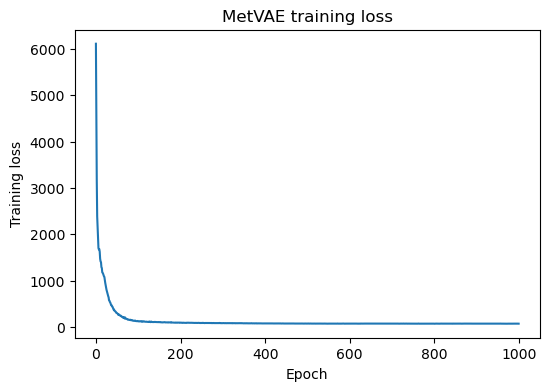

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(model.train_loss)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("MetVAE training loss")
plt.show()

## 5. Estimate correlations

After training, `get_corr()` performs repeated imputations (the default is `num_sim=100`) and builds a correlation estimate.

We set `workers=1` here because that is often more reliable inside notebooks and restricted environments than the default parallel setting.

In [8]:
step_start = time.perf_counter()
corr_outputs = model.get_corr(workers=1)
print_step_time("Estimate correlations", step_start)

print("Objects returned by get_corr():", list(corr_outputs.keys()))

Estimate correlations finished in 0.11 seconds
Objects returned by get_corr(): ['impute_log_data', 'estimate']


In [9]:
# `estimate` is stored as a sparse PyTorch tensor.
# Converting a small corner to dense makes it easier to inspect in a tutorial.
corr_preview = model.corr_outputs["estimate"].to_dense().cpu().numpy()
corr_preview = pd.DataFrame(corr_preview, index=data.columns, columns=data.columns)
display(corr_preview.iloc[:5, :5])

,f0,f1,f2,f3,f4
f0,1.000000,0.615243,0.090651,0.000000,0.000000
f1,0.615243,1.000000,0.207894,0.000000,0.000000
f2,0.090651,0.207894,1.000000,-0.516080,0.089780
f3,0.000000,0.000000,-0.516080,1.000000,-0.060781
f4,0.000000,0.000000,0.089780,-0.060781,1.000000


## 6. Sparsify with p-value filtering

`sparse_by_p()` uses the correlation estimate already stored in the model and applies multiple-testing correction with its default settings.

In [10]:
step_start = time.perf_counter()
results_p = model.sparse_by_p()
print_step_time("P-value sparsification", step_start)

print("Returned objects:", list(results_p.keys()))
display(results_p["sparse_estimate"].iloc[:5, :5])

P-value sparsification finished in 0.02 seconds
Returned objects: ['estimate', 'p_value', 'q_value', 'sparse_estimate']


,f0,f1,f2,f3,f4
f0,1.000000,0.615243,0.00000,0.00000,0.0
f1,0.615243,1.000000,0.00000,0.00000,0.0
f2,0.000000,0.000000,1.00000,-0.51608,0.0
f3,0.000000,0.000000,-0.51608,1.00000,0.0
f4,0.000000,0.000000,0.00000,0.00000,1.0


## 7. Sparsify with SEC

`sparse_by_sec()` is the second built-in sparsification method. It implements the Sparse Estimation of the Correlation matrix (SEC) algorithm to produce a sparse correlation matrix. By default, it searches over a range of penalty values using cross-validation. To keep the notebook practical, we still use `workers = 1`.

In [11]:
step_start = time.perf_counter()
results_sec = model.sparse_by_sec(
    workers=1
)
print_step_time("SEC sparsification", step_start)

print("Best rho:", results_sec["best_rho"])
display(results_sec["sparse_estimate"].iloc[:5, :5])

SEC sparsification finished in 0.20 seconds
Best rho: 1.2746360114795632


,f0,f1,f2,f3,f4
f0,1.000000,0.999062,0.000000,0.000000,0.0
f1,0.999062,1.000000,0.000000,0.000000,0.0
f2,0.000000,0.000000,1.000000,-0.691317,0.0
f3,0.000000,0.000000,-0.691317,1.000000,0.0
f4,0.000000,0.000000,0.000000,0.000000,1.0


## 8. Compare both sparsification methods with the known simulated truth

Because we used simulated data, we also have the true correlation structure. This is useful for learning, but you would not have this in a real dataset.

In [12]:
def summarize_edges(estimated_matrix, true_matrix):
    true_edges = true_matrix[np.tril_indices_from(true_matrix, k=-1)] != 0
    estimated_edges = estimated_matrix[np.tril_indices_from(estimated_matrix, k=-1)] != 0

    tpr = np.sum(estimated_edges & true_edges) / np.sum(true_edges)
    fpr = np.sum(estimated_edges & ~true_edges) / np.sum(~true_edges)
    fdr = np.sum(estimated_edges & ~true_edges) / max(np.sum(estimated_edges), 1)

    return pd.Series({"TPR": tpr, "FPR": fpr, "FDR": fdr})

summary = pd.DataFrame(
    {
        "p_value": summarize_edges(results_p["sparse_estimate"].to_numpy(), true_cor),
        "sec": summarize_edges(results_sec["sparse_estimate"].to_numpy(), true_cor),
    }
).T

display(summary.round(3))

,TPR,FPR,FDR
p_value,0.9,0.003,0.308
sec,0.8,0.000,0.000


## Runtime summary

The table below reports how long each major step took in this notebook run.

In [13]:
runtime_summary = (
    pd.Series(step_times, name="seconds")
    .rename_axis("step")
    .reset_index()
)

display(runtime_summary)
print(f"Total tracked time: {runtime_summary['seconds'].sum():.2f} seconds")

,step,seconds
0,Simulate data,0.006875
1,Initialize model,0.623536
2,Train model,1.165949
3,Estimate correlations,0.107160
4,P-value sparsification,0.022401
5,SEC sparsification,0.195097


Total tracked time: 2.12 seconds
